# Comparing computational performance of different dFBA models

## Functions

### Running dFBA on media samples

In [1]:
import cobra
import numpy as np
import sys

# Uptake kinetics
def v_glc(glc):   # source: 10.1016/S0006-3495(02)73903-9
    Vmax = 10.0    # mmol/gDW/h    
    Ks   = 0.015   # mM
    return Vmax * glc / (Ks + glc)

def v_xyl(xyl, glc):   # source: 10.1049/iet-syb.2013.0021
    Vmax = 9.0    # mmol/gDW/h
    Ks   = 0.01   # mM
    Ki   = 0.01    # mM  
    return Vmax * xyl / (Ks + xyl) * (1 / (1 + glc / Ki))


def run_dfba_samples(
    model,
    samples,
    t_end=20.0,
    dt=0.1,
    initial_biomass=0.03,
    knockouts=None,
    O2_max=5.0,
    mu_threshold=1e-6,
    verbose=False
):

    model = model.copy()

    # Apply knockouts if specified
    if knockouts:
        for g in knockouts:
            if g in model.genes:
                model.genes.get_by_id(g).knock_out()

    EX_glc = model.reactions.get_by_id("EX_glc__D_e")
    EX_xyl = model.reactions.get_by_id("EX_xyl__D_e")
    EX_o2  = model.reactions.get_by_id("EX_o2_e")

    EX_o2.lower_bound = -O2_max

    timesteps = int(t_end / dt)
    results = []   # <-- list of dicts

    n_samples = len(samples)

    for sample_idx, (glc0, xyl0) in enumerate(samples):

        # Progress bar
        if not verbose:
            pct = (sample_idx + 1) / n_samples
            bar = int(30 * pct)
            sys.stdout.write("\r[{}{}] {:3.0f}%".format(
                "#" * bar, "-" * (30 - bar), pct * 100))
            sys.stdout.flush()

        biomass = initial_biomass
        glucose = glc0
        xylose  = xyl0

        time_trace = []
        biomass_trace = []
        glucose_trace = []
        xylose_trace = []

        for step in range(timesteps):

            t = step * dt
            biomass_prev = biomass

            # Uptake bounds
            EX_glc.lower_bound = 0 if glucose <= 1e-9 else -v_glc(glucose)
            EX_xyl.lower_bound = 0 if xylose  <= 1e-9 else -v_xyl(xylose, glucose)

            sol = model.optimize()

            if sol.status != "optimal":
                mu = 0
                glc_uptake = 0
                xyl_uptake = 0
            else:
                mu = sol.objective_value
                glc_uptake = sol.fluxes[EX_glc.id]
                xyl_uptake = sol.fluxes[EX_xyl.id]

            # Stop if growth negligible
            if mu < mu_threshold:
                time_trace.append(t)
                biomass_trace.append(biomass)
                glucose_trace.append(glucose)
                xylose_trace.append(xylose)

                if verbose:
                    print(f"Growth stopped at t={t} for glc={glc0}, xyl={xyl0}")

                # Fill remaining time points
                for k in range(step+1, timesteps):
                    time_trace.append(k * dt)
                    biomass_trace.append(biomass)
                    glucose_trace.append(glucose)
                    xylose_trace.append(xylose)

                break

            # Update biomass
            biomass = biomass_prev * np.exp(mu * dt)

            # Update substrates (using biomass before growth)
            glucose += glc_uptake * biomass_prev * dt
            xylose  += xyl_uptake * biomass_prev * dt

            # Ensure positive concentrations
            glucose = max(glucose, 0)
            xylose  = max(xylose, 0)

            time_trace.append(t)
            biomass_trace.append(biomass)
            glucose_trace.append(glucose)
            xylose_trace.append(xylose)

        # Store results for this sample
        results.append({
            "glc0": glc0,
            "xyl0": xyl0,
            "time": np.array(time_trace),
            "biomass": np.array(biomass_trace),
            "glucose": np.array(glucose_trace),
            "xylose": np.array(xylose_trace),
        })

    if not verbose:
        print()

    return results


### Plotting simulated growth curves

In [231]:
import matplotlib.pyplot as plt

def plot_curves(results, obj="biomass"):
    """
    Plot dFBA curves from list-of-dicts results.
    Colors encode xyl0, line styles encode glc0.
    """

    # Extract unique sorted initial conditions
    glc_vals = sorted({r["glc0"] for r in results})
    xyl_vals = sorted({r["xyl0"] for r in results})

    # Distinct colors (cycled if needed)
    base_colors = [
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
        "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
        "#bcbd22", "#17becf"
    ]

    # Line styles
    line_styles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]

    # Maps
    xyl_to_color = {
        xyl: base_colors[i % len(base_colors)]
        for i, xyl in enumerate(xyl_vals)
    }

    glc_to_style = {
        glc: line_styles[i % len(line_styles)]
        for i, glc in enumerate(glc_vals)
    }

    plt.figure(figsize=(10, 6))

    # Plot all curves
    for r in results:
        time = r["time"]
        y = r[obj]
        plt.plot(
            time, y,
            color=xyl_to_color[r["xyl0"]],
            linestyle=glc_to_style[r["glc0"]],
            linewidth=1.2,
            alpha=0.9
        )

    plt.xlabel("Time (h)")
    plt.ylabel(obj)
    plt.title(f"dFBA curves ({obj})")
    plt.tight_layout()
    plt.show()


### Biomass matrix

In [ ]:
import numpy as np

def biomass_matrix(results):
    """
    Convert list-of-dicts dFBA results into a 2D state matrix:
      biomass_matrix[i, :] = biomass time series for sample i
    """
    n_samples = len(results)
    T = len(results[0]["biomass"])

    M = np.zeros((n_samples, T))

    for i, r in enumerate(results):
        M[i, :] = r["biomass"]

    return M

## Experiments

### Importing the model

In [140]:
from cobra.io import read_sbml_model 
iML1515 = read_sbml_model("models/iML1515.xml")

In [141]:
iML1515.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
ca2_e,EX_ca2_e,0.004565,0,0.00%
cl_e,EX_cl_e,0.004565,0,0.00%
cobalt2_e,EX_cobalt2_e,2.192E-05,0,0.00%
cu2_e,EX_cu2_e,0.0006218,0,0.00%
fe2_e,EX_fe2_e,0.01409,0,0.00%
glc__D_e,EX_glc__D_e,10,6,100.00%
k_e,EX_k_e,0.1712,0,0.00%
mg2_e,EX_mg2_e,0.007608,0,0.00%
mn2_e,EX_mn2_e,0.000606,0,0.00%
mobd_e,EX_mobd_e,6.139E-06,0,0.00%


### Run E. coli model on 100 distinct samples -> Compute Kernel rank

Text(0, 0.5, 'Xylose (mmol/L)')

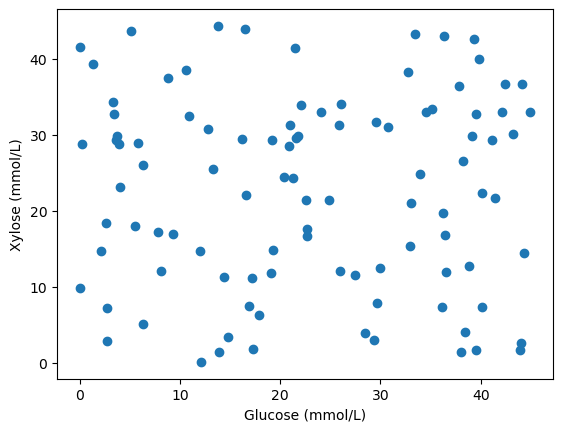

In [138]:
np.random.seed(29)
kr_samples = np.random.uniform(low=[0,0], high=[45,45], size=(100,2))
plt.scatter(kr_samples[:,0],kr_samples[:,1])
plt.xlabel("Glucose (mmol/L)")
plt.ylabel("Xylose (mmol/L)")

In [142]:
import warnings
warnings.filterwarnings("ignore", message="Solver status is 'infeasible'")

results = run_dfba_samples(iML1515, kr_samples)

[##############################] 100%


In [ ]:
import pickle
with open("kr_datasets/iML1515_GX.pkl", "wb") as f:
    pickle.dump(results, f)

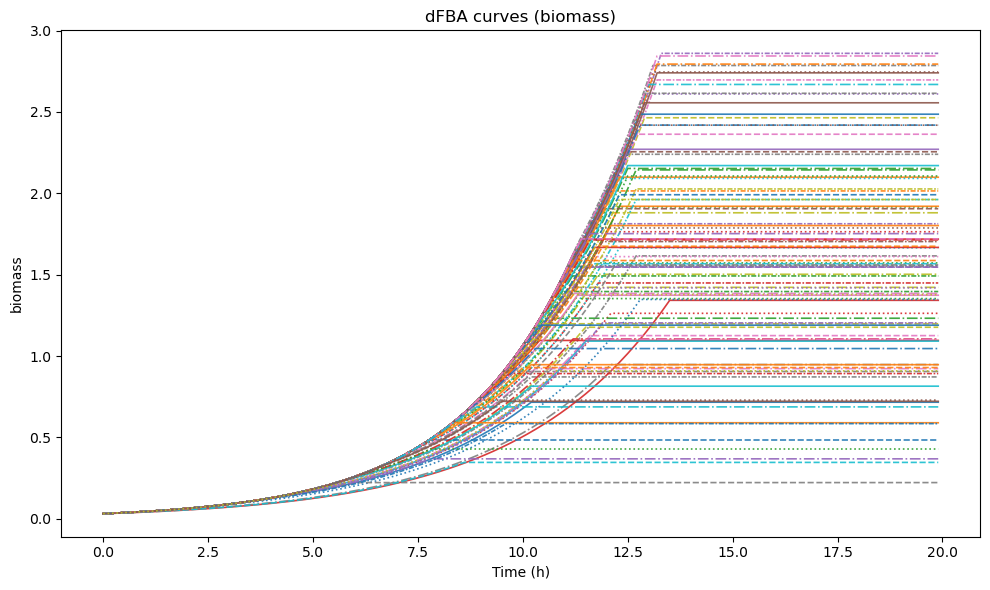

In [234]:
plot_curves(results)

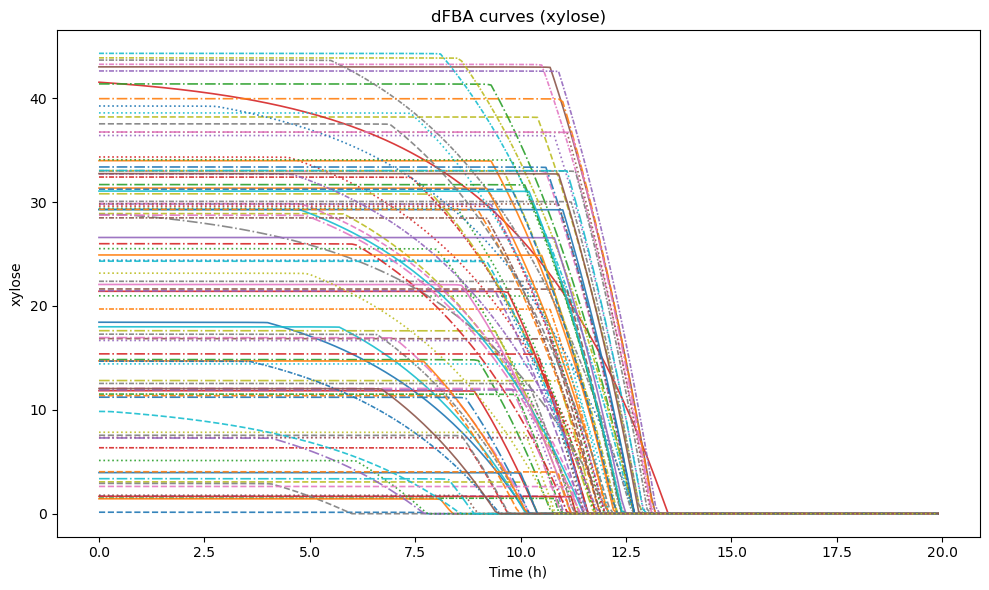

In [235]:
plot_curves(results,"xylose")

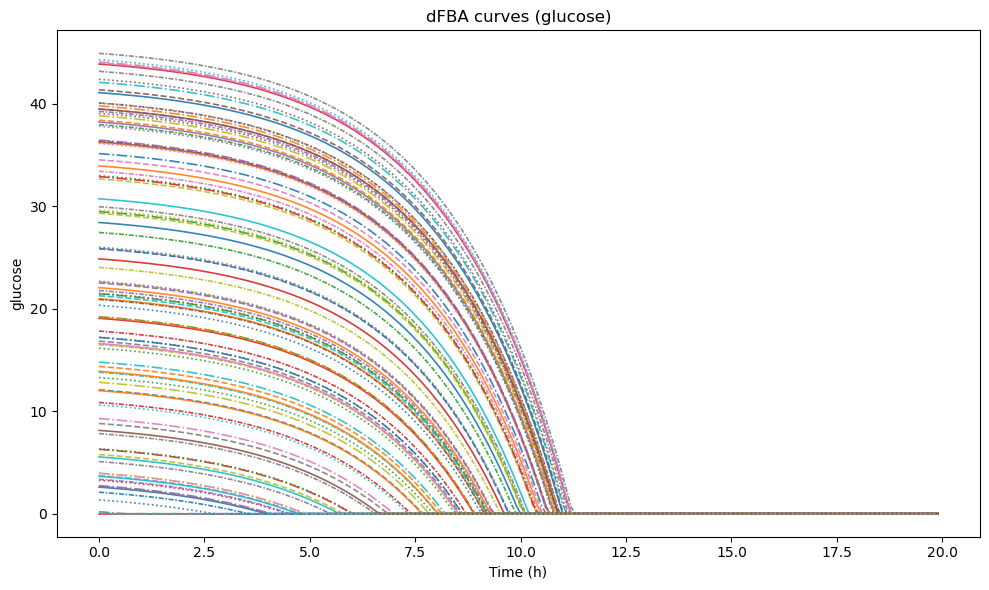

In [236]:
plot_curves(results,"glucose")

In [ ]:
bm = biomass_matrix(results)
np.linalg.matrix_rank(bm)

np.int64(86)

### Run E. coli model on noisy variations of 5 templates -> Compute Generalisation rank

Text(0, 0.5, 'Xylose (mmol/L)')

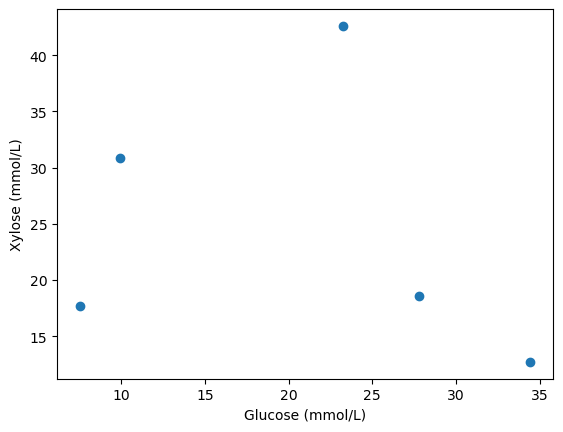

In [239]:
np.random.seed(23)
templates = np.random.uniform(low=[0,0], high=[45,45], size=(5,2))
plt.scatter(templates[:,0],templates[:,1])
plt.xlabel("Glucose (mmol/L)")
plt.ylabel("Xylose (mmol/L)")

In [240]:
gr_samples = []
noise_std = 0.2

for i, tpl in enumerate(templates):
    samples = tpl + np.random.normal(0, noise_std, size=(20,2))

    gr_samples.extend(samples)

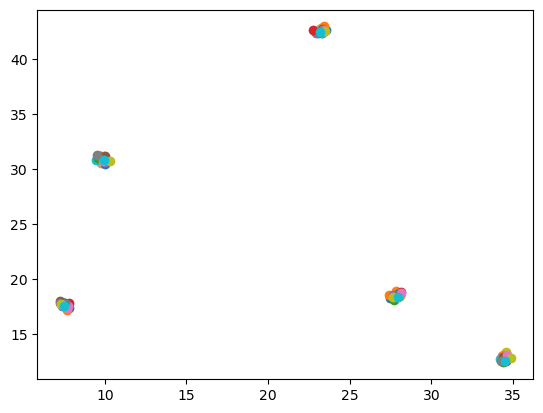

In [ ]:
for sample in gr_samples:
    plt.scatter(sample[0],sample[1])
plt.xlabel("Glucose (mmol/L)")
plt.ylabel("Xylose (mmol/L)")

In [245]:
import warnings
warnings.filterwarnings("ignore", message="Solver status is 'infeasible'")

results = run_dfba_samples(iML1515, gr_samples)
with open("gr_datasets/iML1515_GX.pkl", "wb") as f:
    pickle.dump(results, f)

[##############################] 100%


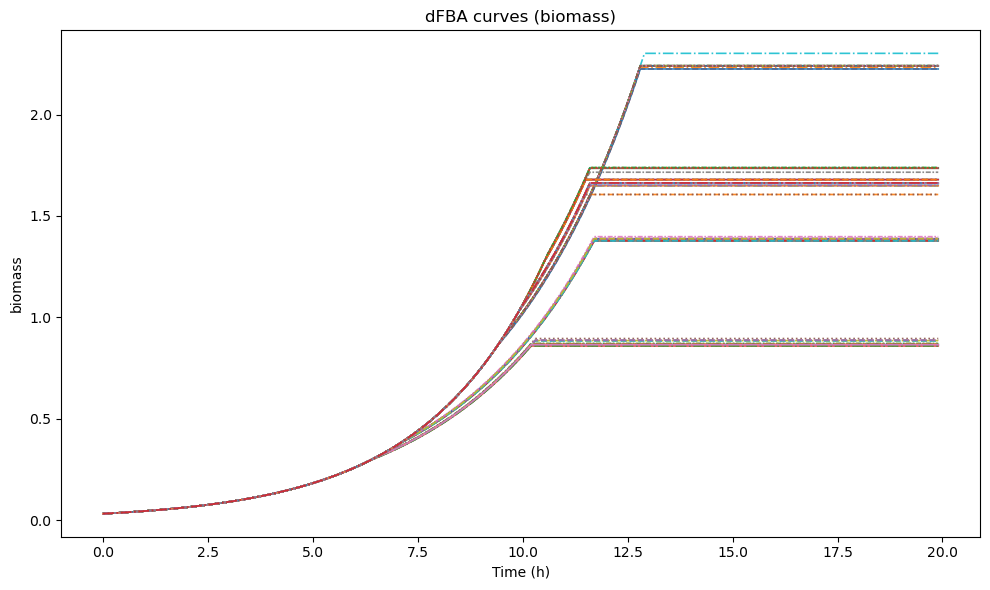

In [247]:
plot_curves(results)

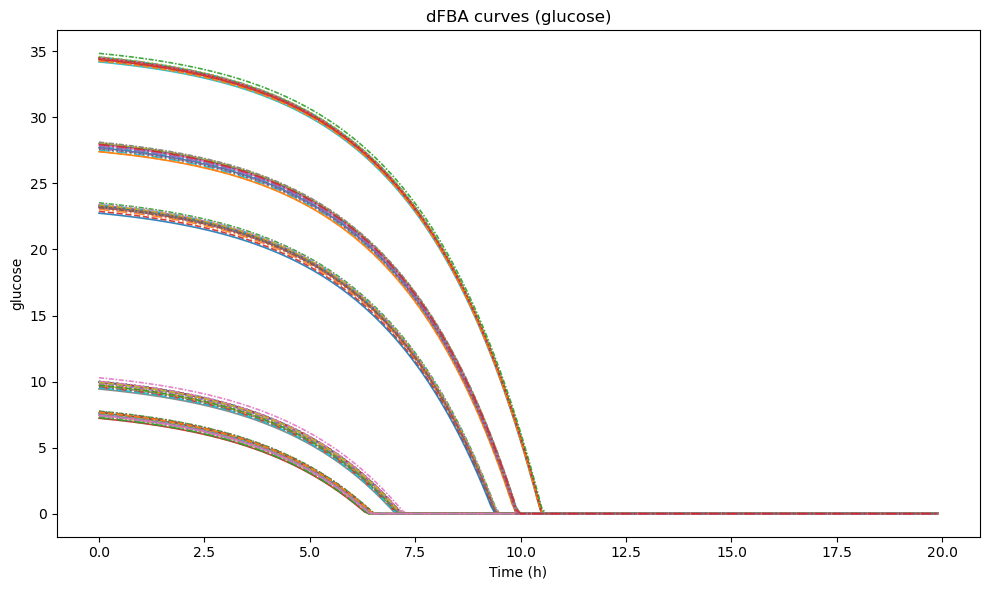

In [248]:
plot_curves(results, "glucose")

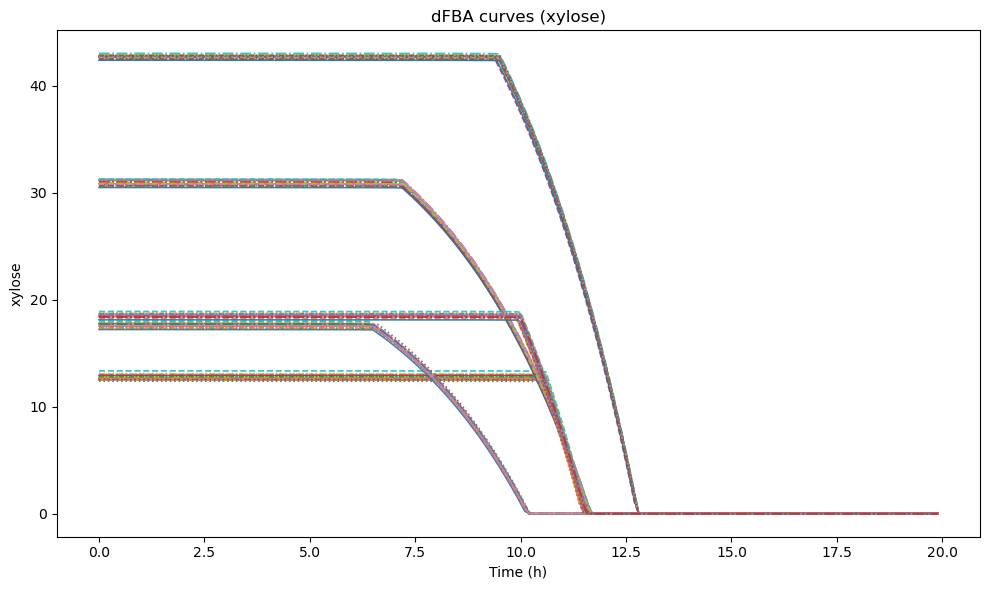

In [249]:
plot_curves(results, "xylose")

In [155]:
bm = biomass_matrix(results)
np.linalg.matrix_rank(bm)

np.int64(49)

### Run performance test on E. coli model

In [8]:
import numpy as np
import pickle

def generate_performance_dataset(
    model,
    templates,
    knockouts=None,
    n_train=20,
    n_test=5,
    noise_std=0.2,
    filename="perf_dataset.pkl"
):
    """
    Generate noisy samples from templates, run dFBA, and store:
      - templates
      - train_samples, test_samples
      - template index for each sample
      - biomass matrices
      - time vector
    """

    # --- 1. Generate noisy samples ---
    train_samples = []
    test_samples  = []
    train_template_idx = []
    test_template_idx  = []

    for i, tpl in enumerate(templates):
        train = tpl + np.random.normal(0, noise_std, size=(n_train,2))
        test  = tpl + np.random.normal(0, noise_std, size=(n_test,2))

        train_samples.extend(train)
        test_samples.extend(test)

        train_template_idx.extend([i]*n_train)
        test_template_idx.extend([i]*n_test)

    # --- 2. Run dFBA ---
    train_results = run_dfba_samples(model, train_samples, knockouts=knockouts)
    test_results  = run_dfba_samples(model, test_samples, knockouts=knockouts)

    # --- 3. Convert to biomass matrices ---
    biomass_train = biomass_matrix(train_results)
    biomass_test  = biomass_matrix(test_results)

    # --- 4. Store everything ---
    dataset = {
        "templates": np.array(templates),
        "train_samples": np.array(train_samples),
        "test_samples": np.array(test_samples),
        "train_template_idx": np.array(train_template_idx),
        "test_template_idx": np.array(test_template_idx),
        "biomass_train": biomass_train,
        "biomass_test": biomass_test,
        "time": train_results[0]["time"],
    }

    with open(filename, "wb") as f:
        pickle.dump(dataset, f)

    print(f"Dataset saved to {filename}")


In [ ]:
import numpy as np
from sklearn.linear_model import RidgeClassifierCV

def evaluate_performance(dataset, n_tasks=100):
    """
    Perform n_tasks random binary classification tasks.
    For each task:
      - Assign random binary labels to the 20 templates
      - Train linear readout on growth curves (biomass)
      - Train linear readout on raw sample data
      - Evaluate accuracy on test set

    Returns:
      mean_accuracy_growth, mean_accuracy_input
    """

    # Unpack dataset
    templates = dataset["templates"]
    train_samples = dataset["train_samples"]
    test_samples  = dataset["test_samples"]
    train_idx = dataset["train_template_idx"]
    test_idx  = dataset["test_template_idx"]
    X_train_growth = dataset["biomass_train"]
    X_test_growth  = dataset["biomass_test"]

    acc_growth_list = []
    acc_input_list  = []

    for _ in range(n_tasks):

        # --- 1. Random binary labels for templates ---
        template_labels = np.random.choice([0,1], size=len(templates))

        y_train = template_labels[train_idx]
        y_test  = template_labels[test_idx]

        # --- 2. Linear readout on growth curves ---
        clf_growth = RidgeClassifierCV(alphas=[1e-3, 1e-2, 1e-1, 1])
        clf_growth.fit(X_train_growth, y_train)
        acc_growth = clf_growth.score(X_test_growth, y_test)
        acc_growth_list.append(acc_growth)

        # --- 3. Linear readout on raw input samples ---
        clf_input = RidgeClassifierCV(alphas=[1e-3, 1e-2, 1e-1, 1])
        clf_input.fit(train_samples, y_train)
        acc_input = clf_input.score(test_samples, y_test)
        acc_input_list.append(acc_input)

    # --- 4. Report accuracies ---
    return {
        "mean growth" : np.mean(acc_growth_list),
        "std growth" : np.std(acc_growth_list),
        "mean input" : np.mean(acc_input_list),
        "std input" : np.std(acc_input_list)
    }

Text(0, 0.5, 'Xylose (mmol/L)')

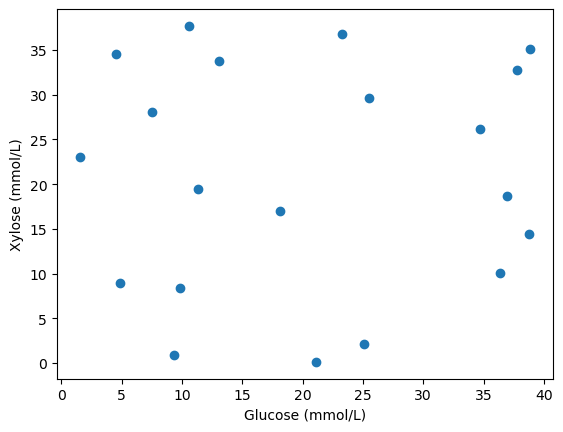

In [ ]:
templates = np.random.uniform(low=[0,0], high=[45,45], size=(20,2))
plt.scatter(templates[:,0],templates[:,1])
plt.xlabel("Glucose (mmol/L)")
plt.ylabel("Xylose (mmol/L)")

In [121]:
generate_performance_dataset(iML1515,templates,filename="perf_datasets/iML1515_GX.pkl")

[##############################] 100%
[##############################] 100%
Dataset saved to perf_datasets/iML1515_GX.pkl


In [44]:
with open("perf_datasets/iML1515_GX.pkl", "rb") as f:
    data = pickle.load(f)

acc_results = evaluate_performance(data)

print("Mean accuracy (growth curves):", acc_results["mean growth"])
print("Mean accuracy (raw inputs):   ", acc_results["mean input"])

Mean accuracy (growth curves): 0.9937900000000001
Mean accuracy (raw inputs):    0.65641


### Running experiments on E. coli mutants

Finding interesting mutants

In [7]:
from cobra.flux_analysis import single_gene_deletion

with iML1515:
    for ex in ["EX_glc__D_e","EX_xyl__D_e"]:
        iML1515.reactions.get_by_id(ex).lower_bound = -1000
    wt_growth = iML1515.slim_optimize()
    ko_df = single_gene_deletion(iML1515)
    ko_df["growth_ratio"] = ko_df["growth"] / wt_growth
    interesting = ko_df[(ko_df["growth_ratio"] > 0.05) & (ko_df["growth_ratio"] < 0.95)]
    print(interesting)
    interesting_genes = interesting.ids.tolist()
    with open("genes_glcxyl_sd.txt", "w") as f:
        for g in interesting_genes:
            f.write(next(iter(g)) + "\n")

          ids     growth   status  growth_ratio
110   {b3737}  18.896651  optimal      0.723562
207   {b2278}  24.691045  optimal      0.945433
215   {b0429}  24.790792  optimal      0.949252
230   {b3734}  18.896651  optimal      0.723562
286   {b2288}  24.691045  optimal      0.945433
325   {b2282}  24.691045  optimal      0.945433
371   {b2284}  24.691045  optimal      0.945433
376   {b2279}  24.691045  optimal      0.945433
493   {b0430}  24.790792  optimal      0.949252
497   {b2281}  24.691045  optimal      0.945433
553   {b1779}  13.713055  optimal      0.525080
590   {b0431}  24.790792  optimal      0.949252
596   {b2285}  24.691045  optimal      0.945433
609   {b2779}  18.704508  optimal      0.716205
772   {b3733}  18.896651  optimal      0.723562
825   {b0010}  24.058818  optimal      0.921225
862   {b2926}  13.713055  optimal      0.525080
892   {b3738}  18.896651  optimal      0.723562
929   {b2276}  24.691045  optimal      0.945433
982   {b3735}  18.896651  optimal      0

In [157]:
import pickle

def run_mutant_experiments(
    model,
    samples,
    knockout_file,
    experiment="iML1515_mut",
    output_dir="dfba_outputs"
):
    """
    Run dFBA simulations for a list of mutants defined in a text file.
    
    knockout_file: text file where each line contains gene IDs separated by commas.
                   Lines may contain 'None' for genes not found in the model → skip.
    samples: array of (glc0, succ0) pairs for run_dfba_samples
    """

    # Read knockout definitions
    with open(knockout_file, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    for i, line in enumerate(lines, start=1):

        # Parse gene IDs
        genes = [g.strip() for g in line.split(",")]

        # Skip mutants containing "None"
        if any(g == "None" for g in genes):
            print(f"Skipping mutant line {i}: contains None → {line}")
            continue

        print(f"Running mutant {i}: {genes}")

        # Run dFBA for this mutant
        results = run_dfba_samples(
            model,
            samples,
            knockouts=genes
        )

        # Save results
        exp_name = f"{experiment}_{i}"
        with open(f"{output_dir}/{exp_name}.pkl", "wb") as f:
            pickle.dump(results, f)

        print(f"Saved {exp_name}.pkl")


Kernel rank dataset

In [158]:
import warnings
warnings.filterwarnings("ignore", message="Solver status is 'infeasible'")

run_mutant_experiments(
    model=iML1515,
    samples=kr_samples,
    knockout_file="genes_GX_sd.txt",
    output_dir="kr_datasets/iML1515_GX_muts",
    experiment="mut"
)

Running mutant 1: ['b3737']
[##############################] 100%
Saved mut_1.pkl
Running mutant 2: ['b2278']
[##############################] 100%
Saved mut_2.pkl
Running mutant 3: ['b0429']
[##############################] 100%
Saved mut_3.pkl
Running mutant 4: ['b3734']
[##############################] 100%
Saved mut_4.pkl
Running mutant 5: ['b2288']
[##############################] 100%
Saved mut_5.pkl
Running mutant 6: ['b2282']
[##############################] 100%
Saved mut_6.pkl
Running mutant 7: ['b2284']
[##############################] 100%
Saved mut_7.pkl
Running mutant 8: ['b2279']
[##############################] 100%
Saved mut_8.pkl
Running mutant 9: ['b0430']
[##############################] 100%
Saved mut_9.pkl
Running mutant 10: ['b2281']
[##############################] 100%
Saved mut_10.pkl
Running mutant 11: ['b1779']
[##############################] 100%
Saved mut_11.pkl
Running mutant 12: ['b0431']
[##############################] 100%
Saved mut_12.pkl
Running mu

Generalisation rank datset

In [159]:
import warnings
warnings.filterwarnings("ignore", message="Solver status is 'infeasible'")

run_mutant_experiments(
    model=iML1515,
    samples=gr_samples,
    knockout_file="genes_GX_sd.txt",
    output_dir="gr_datasets/iML1515_GX_muts",
    experiment="mut"
)

Running mutant 1: ['b3737']
[##############################] 100%
Saved mut_1.pkl
Running mutant 2: ['b2278']
[##############################] 100%
Saved mut_2.pkl
Running mutant 3: ['b0429']
[##############################] 100%
Saved mut_3.pkl
Running mutant 4: ['b3734']
[##############################] 100%
Saved mut_4.pkl
Running mutant 5: ['b2288']
[##############################] 100%
Saved mut_5.pkl
Running mutant 6: ['b2282']
[##############################] 100%
Saved mut_6.pkl
Running mutant 7: ['b2284']
[##############################] 100%
Saved mut_7.pkl
Running mutant 8: ['b2279']
[##############################] 100%
Saved mut_8.pkl
Running mutant 9: ['b0430']
[##############################] 100%
Saved mut_9.pkl
Running mutant 10: ['b2281']
[##############################] 100%
Saved mut_10.pkl
Running mutant 11: ['b1779']
[##############################] 100%
Saved mut_11.pkl
Running mutant 12: ['b0431']
[##############################] 100%
Saved mut_12.pkl
Running mu

Performance dataset

In [ ]:
import warnings
import os
warnings.filterwarnings("ignore", message="Solver status is 'infeasible'")

with open("genes_GX_sd.txt", "r") as f:
    lines = [line.strip() for line in f if line.strip()]

for i, line in enumerate(lines, start=1):
    exp_name=f"perf_datasets/iML1515_GX_muts/iML1515_GX_mut_{i}.pkl"
    if os.path.exists(exp_name):
        print(f"Skipping mutant {i}, files already exist")
        continue

    # Parse gene IDs
    genes = [g.strip() for g in line.split(",")]

    # Skip mutants containing "None"
    if any(g == "None" for g in genes):
        print(f"Skipping mutant line {i}: contains None → {line}")
        continue

    print(f"Running mutant {i}: {genes}")

    # Run dFBA for this mutant
    generate_performance_dataset(iML1515,templates,filename=exp_name, knockouts=genes)

Running mutant 3: ['b0429']
[##############################] 100%
[##############################] 100%
Dataset saved to perf_datasets/iML1515_GX_muts/iML1515_GX_mut_3.pkl
Saved perf_datasets/iML1515_GX_muts/iML1515_GX_mut_3.pkl
Running mutant 4: ['b3734']
[##############################] 100%
[##############################] 100%
Dataset saved to perf_datasets/iML1515_GX_muts/iML1515_GX_mut_4.pkl
Saved perf_datasets/iML1515_GX_muts/iML1515_GX_mut_4.pkl
Running mutant 5: ['b2288']
[##############################] 100%
[##############################] 100%
Dataset saved to perf_datasets/iML1515_GX_muts/iML1515_GX_mut_5.pkl
Saved perf_datasets/iML1515_GX_muts/iML1515_GX_mut_5.pkl
Running mutant 6: ['b2282']
[##############################] 100%
[##############################] 100%
Dataset saved to perf_datasets/iML1515_GX_muts/iML1515_GX_mut_6.pkl
Saved perf_datasets/iML1515_GX_muts/iML1515_GX_mut_6.pkl
Running mutant 7: ['b2284']
[##############################] 100%
[#################

Calculate ranks and evaluate performance for each mutant

In [ ]:
import os
import numpy as np
import pandas as pd
import pickle

mutant_dir = "perf_datasets/iML1515_GX_muts"
files = [fname for fname in os.listdir(mutant_dir) if fname.endswith(".pkl")]

summary_rows = []

for fname in files:
    exp_name = fname.replace(".pkl", "")

    # Load performance dataset
    with open(f"perf_datasets/iML1515_GX_muts/{fname}", "rb") as fh:
        data = pickle.load(fh)

    # Evaluate performance
    acc_results = evaluate_performance(data)

    # Load dfba outputs
    with open(f"dfba_outputs/iML1515_GX_muts/{fname}", "rb") as fh:
        data = pickle.load(fh)

    # Compute kernel rank
    bm = biomass_matrix(data)
    k_rank = np.linalg.matrix_rank(bm)

    # Load growth rate datasets
    with open(f"gr_datasets/iML1515_GX_muts/{fname}", "rb") as fh:
        data = pickle.load(fh)

    # Compute generalisation rank
    bm = biomass_matrix(data)
    g_rank = np.linalg.matrix_rank(bm)

    # Save experiment results
    summary_rows.append({
        "mutant": exp_name,
        "ker rank": k_rank,
        "gen rank": g_rank,
        "mean acc curves": round(acc_results["mean growth"],4),
        "std acc curves": round(acc_results["std growth"],4),
        "mean acc input": round(acc_results["mean input"],4),
        "std acc input": round(acc_results["std input"],4)
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("iML1515_GX_muts_analysis.csv", index=False)

summary_df


,mutant,ker rank,gen rank,mean acc curves,std acc curves,mean acc input,std acc input
0,iML1515_GX_mut_1,64,49,0.9989,0.0034,0.6585,0.0823
1,iML1515_GX_mut_10,64,48,0.9989,0.0040,0.6719,0.0823
2,iML1515_GX_mut_11,15,13,0.6337,0.0564,0.6435,0.0820
3,iML1515_GX_mut_12,64,48,0.9959,0.0055,0.6666,0.0920
4,iML1515_GX_mut_13,64,48,0.9986,0.0055,0.6586,0.0800
5,iML1515_GX_mut_14,64,42,0.8667,0.0435,0.6565,0.0796
6,iML1515_GX_mut_15,64,49,0.9986,0.0045,0.6574,0.0746
7,iML1515_GX_mut_16,64,47,0.9998,0.0014,0.6391,0.0849
8,iML1515_GX_mut_17,15,13,0.6517,0.0680,0.6660,0.0913
9,iML1515_GX_mut_18,64,49,0.9959,0.0060,0.6561,0.0895


### Run experiments on other microbial models

Generate datasets

In [ ]:
from cobra.io import read_sbml_model
import os
import pickle
iML1515 = read_sbml_model("models/iML1515.xml")
files = [fname for fname in os.listdir("models") if fname.endswith(".xml")]
for file in files:
    GEM = read_sbml_model(f"models/{file}")
    exp_name = file.strip(".xml")
    print(f"Running model {file}")

    if os.path.exists(f"kr_datasets/{exp_name}_GX.pkl"):
        print(f"Skipping {exp_name}, files already exist")
        continue

    try:
        results = run_dfba_samples(GEM, kr_samples)
    except:
        print(f"Couldn't run {exp_name}")   # Some models lack xylose and can't be used for this experiment
        continue

    with open(f"kr_datasets/{exp_name}_GX.pkl", "wb") as f:
        pickle.dump(results, f)
    print(f"Saved kernel dataset: {exp_name}.pkl")

    results = run_dfba_samples(GEM, gr_samples)

    with open(f"gr_datasets/{exp_name}_GX.pkl", "wb") as f:
        pickle.dump(results, f)
    print(f"Saved generalisation dataset: {exp_name}.pkl")

    generate_performance_dataset(GEM, templates, filename=f"perf_datasets/{exp_name}_GX.pkl")

Running model iEK1008.xml
Couldn't run iEK1008
Running model iIT341.xml
Couldn't run iIT341
Running model iJN1463.xml
Couldn't run iJN1463
Running model iML1515.xml
[##############################] 100%
Saved kernel dataset: iML1515.pkl
[##############################] 100%
Saved generalisation dataset: iML1515.pkl
Running model iMM904.xml
[##############################] 100%
Saved kernel dataset: iMM904.pkl
[##############################] 100%
Saved generalisation dataset: iMM904.pkl
Running model iNF517.xml
Couldn't run iNF517
Running model iPC815.xml
[##############################] 100%
Saved kernel dataset: iPC815.pkl
[##############################] 100%
Saved generalisation dataset: iPC815.pkl
Running model iYO844.xml
[##############################] 100%
Saved kernel dataset: iYO844.pkl
[##############################] 100%
Saved generalisation dataset: iYO844.pkl
Running model iYS1720.xml
[##############################] 100%
Saved kernel dataset: iYS1720.pkl
[##############

Compute ranks and evaluate performance

In [74]:
import os
import numpy as np
import pandas as pd
import pickle

dir = "perf_datasets"
files = [fname for fname in os.listdir(dir) if fname.endswith(".pkl")]

summary_rows = []

for fname in files:
    exp_name = fname.replace(".pkl", "")

    # Load performance dataset
    with open(f"perf_datasets/{fname}", "rb") as fh:
        data = pickle.load(fh)

    acc_results = evaluate_performance(data)

    # Load dfba outputs
    with open(f"kr_datasets/{fname}", "rb") as fh:
        data = pickle.load(fh)

    bm = biomass_matrix(data)
    k_rank = np.linalg.matrix_rank(bm)

    # Load growth rate datasets
    with open(f"gr_datasets/{fname}", "rb") as fh:
        data = pickle.load(fh)

    bm = biomass_matrix(data)
    g_rank = np.linalg.matrix_rank(bm)

    summary_rows.append({
        "mutant": exp_name,
        "ker rank": k_rank,
        "gen rank": g_rank,
        "mean acc curves": round(acc_results["mean growth"],4),
        "std acc curves": round(acc_results["std growth"],4),
        "mean acc input": round(acc_results["mean input"],4),
        "std acc input": round(acc_results["std input"],4)
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("multispecies_GX_analysis.csv", index=False)

summary_df


,mutant,ker rank,gen rank,mean acc curves,std acc curves,mean acc input,std acc input
0,iCN718_GX,36,17,0.5595,0.1065,0.6544,0.0814
1,iML1515_GX,64,43,0.9976,0.0063,0.6614,0.0771
2,iMM904_GX,64,46,0.9932,0.0124,0.6538,0.0832
3,iPC815_GX,16,6,0.6868,0.0644,0.6655,0.0866
4,iYO844_GX,64,48,0.9978,0.0041,0.6674,0.0915
5,iYS1720_GX,64,44,0.9948,0.0092,0.6465,0.0710
6,iYS854_GX,45,31,0.9191,0.0432,0.6610,0.0801


## Time - Accuracy tradeoff

Recompute ranks and performance values for different experiment lengths

In [161]:
import os
import numpy as np
import pandas as pd
import pickle

def tradeoff_analysis(filename):

    # Load performance dataset for the selected model
    with open(f"perf_datasets/{filename}.pkl", "rb") as fh:
        perf_data = pickle.load(fh)

    # Load dfba outputs for the selected model
    with open(f"kr_datasets/{filename}.pkl", "rb") as fh:
        kr_data = pickle.load(fh)

    # Load growth rate datasets for the selected model
    with open(f"gr_datasets/{filename}.pkl", "rb") as fh:
        gr_data = pickle.load(fh)

    # Get biomass matrices
    kr_biomass_matrix = biomass_matrix(kr_data)
    gr_biomass_matrix = biomass_matrix(gr_data)

    # Prepare results tracking
    results = []

    # Get the original time dimension (number of timepoints)
    original_timepoints = len(perf_data["time"])

    # Iteratively reduce the biomass matrices and evaluate performance
    for i in range(1, original_timepoints):  # Start from 1 to avoid empty matrices
        # Reduce biomass matrices by removing last timepoint (column)
        reduced_kr_biomass = kr_biomass_matrix[:, :-i] if i < kr_biomass_matrix.shape[1] else np.array([]).reshape(kr_biomass_matrix.shape[0], 0)
        reduced_gr_biomass = gr_biomass_matrix[:, :-i] if i < gr_biomass_matrix.shape[1] else np.array([]).reshape(gr_biomass_matrix.shape[0], 0)
        
        # Create reduced performance dataset by trimming biomass arrays
        reduced_perf_data = perf_data.copy()
    
        # Trim biomass_train and biomass_test to remove last i timepoints
        if len(reduced_perf_data["biomass_train"]) > 1:
            reduced_perf_data["biomass_train"] = reduced_perf_data["biomass_train"][:, :-i]
        if len(reduced_perf_data["biomass_test"]) > 1:
            reduced_perf_data["biomass_test"] = reduced_perf_data["biomass_test"][:, :-i]
        
        # Update time array to reflect reduced timepoints
        if len(reduced_perf_data["time"]) > 1:
            reduced_perf_data["time"] = reduced_perf_data["time"][:-i]
        
        # Evaluate performance on reduced dataset
        acc_results = evaluate_performance(reduced_perf_data)
        
        # Calculate ranks using the reduced biomass matrices
        k_rank = np.linalg.matrix_rank(reduced_kr_biomass) if reduced_kr_biomass.size > 0 else 0
        g_rank = np.linalg.matrix_rank(reduced_gr_biomass) if reduced_gr_biomass.size > 0 else 0
    
        # Store results
        results.append({
            "timepoints_reduced": i,
            "remaining_timepoints": original_timepoints - i,
            "ker_rank": k_rank,
            "gen_rank": g_rank,
            "mean_acc_curves": round(acc_results["mean growth"], 4),
            "std_acc_curves": round(acc_results["std growth"], 4),
            "mean_acc_input": round(acc_results["mean input"], 4),
            "std_acc_input": round(acc_results["std input"], 4)
        })

    # Convert to DataFrame and save
    results_df = pd.DataFrame(results)
    results_df.to_csv(f"tradeoff_analysis/{filename}.csv", index=False)
    print(f"Saved {filename}.csv")
    return results_df